In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

In [2]:
np.random.seed(42)

n = 120

data = {
    "Age": np.random.randint(18, 60, n),
    "Annual Income": np.random.randint(30, 200, n),
    "Spending Score": np.random.randint(10, 100, n),
    "Transaction Count": np.random.randint(1, 60, n),
}

df = pd.DataFrame(data)
df.head()

,Age,Annual Income,Spending Score,Transaction Count
0,56,171,21,15
1,46,132,78,28
2,32,56,46,34
3,25,166,41,2
4,38,44,18,32


In [3]:
# normalize the data
# pick the features for clustering
features = ["Age", "Annual Income", "Spending Score", "Transaction Count"]

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.head()

,Age,Annual Income,Spending Score,Transaction Count
0,1.448425,1.020876,-1.257223,-1.017680
1,0.641503,0.193712,1.184402,-0.262049
2,-0.488188,-1.418198,-0.186335,0.086704
3,-1.053033,0.914829,-0.400512,-1.773311
4,-0.004035,-1.672710,-1.385729,-0.029547


In [4]:
# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_data)

df["Cluster"] = kmeans.labels_
df.head()

,Age,Annual Income,Spending Score,Transaction Count,Cluster
0,56,171,21,15,1
1,46,132,78,28,0
2,32,56,46,34,2
3,25,166,41,2,2
4,38,44,18,32,2


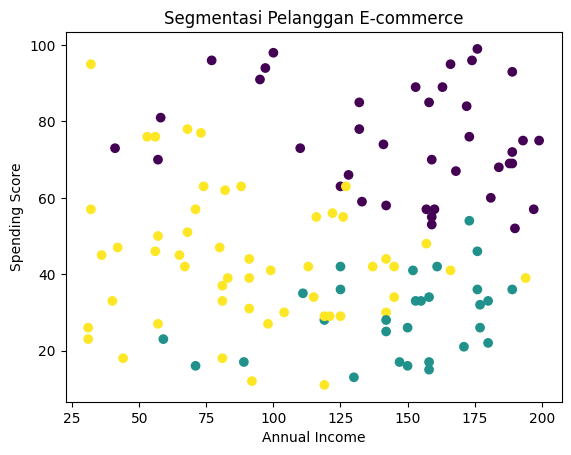

In [5]:
plt.Figure()
plt.scatter(df["Annual Income"], df["Spending Score"], c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Segmentasi Pelanggan E-commerce")
plt.show()

In [6]:
df.groupby("Cluster").mean()

,Age,Annual Income,Spending Score,Transaction Count
Cluster,,,,
0,40.641026,147.794872,74.897436,34.333333
1,49.103448,146.689655,29.068966,35.862069
2,29.942308,90.884615,43.807692,29.269231
